## IV – Data Preprocessing & Feature Engineering

## IV – Prétraitement des Données & Ingénierie des Variables
---

Avant de construire nos modèles prédictifs, il est essentiel de **préparer les données** et de **créer des variables pertinentes** qui capturent les facteurs influençant le défaut de prêt.  

Cette étape comprend :  
- La **normalisation et transformation** des variables numériques.  
- Le **codage des variables catégorielles** pour les rendre exploitables par les modèles.  
- La **création de nouvelles features** pouvant améliorer la capacité prédictive du modèle.  
- La gestion des **valeurs aberrantes** et le traitement des éventuelles **incohérences** restantes.

Un prétraitement rigoureux permet d’**optimiser les performances des modèles** et d’obtenir des insights fiables pour la prise de décision dans un contexte bancaire.


#### Importation des bibliothèques et outils pour le prétraitement des données et la modélisation


In [ ]:
# -----------------------------
# Data Handling
# -----------------------------
import pandas as pd
import numpy as np
import math
import os

# -----------------------------
# Data Visualization
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

sns.set(style="whitegrid")
plt.style.use("seaborn-darkgrid")

# -----------------------------
# Data Preprocessing & Feature Engineering
# -----------------------------
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# -----------------------------
# Machine Learning Models
# -----------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import xgboost as xgb
from xgboost import XGBClassifier

# import lightgbm as lgb
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# -----------------------------
# Model Evaluation Metrics
# -----------------------------
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, roc_curve
)

# -----------------------------
# Miscellaneous
# -----------------------------
import warnings
warnings.filterwarnings("ignore")


### Importation du dataset Loan_clean

In [2]:
# -----------------------------
# Importation du dataset Loan_clean

# Définir le chemin relatif vers le fichier CSV
data_path = "../Data/Loan_clean.csv"

# Charger le dataset
loan = pd.read_csv(data_path)

# Afficher les premières lignes pour vérifier l'import
loan.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Default_label_fr,Loan_to_Income
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0,Remboursé à temps (Prêt sain),0.588262
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0,Remboursé à temps (Prêt sain),2.467481
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1,Défaut de remboursement (Prêt à risque),1.534154
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0,Remboursé à temps (Prêt sain),1.412638
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0,Remboursé à temps (Prêt sain),0.447179


In [3]:
# Shorter and clean labels for visualization
loan['Default_label_fr_short'] = loan['Default'].map({
    0: "Remboursé",
    1: "Défaut"
})
loan.shape


(255347, 21)

In [4]:
# 1️ Définir les Features (X) et la Cible (y)
# -----------------------------
# Supprimer toutes les colonnes non pertinentes, y compris la variable cible
drop_cols = ['LoanID', 'Default', 'Default_label_fr', 'Default_label_fr_short']  # éviter toute fuite de la cible
X = loan.drop(columns=drop_cols)
y = loan['Default']  # 0 = Remboursé, 1 = Défaut

In [5]:
# 2️ Identifier les types de variables
# -----------------------------
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

✅ Colonnes numériques : ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Loan_to_Income']
✅ Colonnes catégorielles : ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


In [6]:
# 3️ Créer les pipelines de prétraitement

# Pipeline pour les variables numériques
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # Remplacer les valeurs manquantes par la médiane
    ('scaler', StandardScaler())                     # Standardiser les variables numériques
])

# Pipeline pour les variables catégorielles
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),   # Remplacer les valeurs manquantes par la modalité la plus fréquente
    ('encoder', OneHotEncoder(drop='first', sparse=False))  # Encoder en One-Hot (évite la colinéarité)
])

# Combiner les deux pipelines dans un transformateur de colonnes
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

In [7]:
# 4️ Séparer le dataset en Train et Test
# -----------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,    
    random_state=42, stratify=y )

# -----------------------------
# 5️ Appliquer le pipeline de prétraitement
# -----------------------------
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

À l'issue du prétraitement, notre jeu de données est **nettoyé, transformé et prêt pour l'entraînement des modèles de machine learning**. Toutes les variables numériques et catégorielles ont été adaptées, les colonnes inutiles supprimées, et de nouvelles colonnes dérivées ajoutées pour enrichir l'analyse. 

Ces étapes garantissent que les modèles puissent apprendre efficacement et que les résultats soient interprétables dans un contexte business.


 ## V (Modeling) Modélisation et Prédiction du Risque de Défaut
---

Dans cette section, nous allons construire et évaluer des **modèles de machine learning** pour prédire le risque de défaut de remboursement des prêts. L’objectif est de transformer les données prétraitées en **insights quantitatifs exploitables**, permettant aux institutions financières de :

- **Identifier de manière proactive les emprunteurs à risque élevé**,  
- **Réduire les pertes liées aux prêts non performants**,  
- **Optimiser les décisions de crédit et les stratégies de prêt**,  
- **Renforcer la stabilité financière globale**.  

Nous explorerons deux grandes approches de modélisation :  

### 1️. Logistic Regression (Baseline)
- Modèle simple et interprétable, servant de **référence (baseline)**. Et permet de comprendre l’impact des variables sur le risque de défaut.

### 2. Optimized Models 

#### a) Random Forest (Modèle Optimisé)
- Modèle d’ensemble capable de capturer des relations complexes, Améliore la détection des emprunteurs à risque par rapport à la baseline.
- Hyperparamètres ajustables pour optimiser la performance.

#### b) XGBoost  (Modèle Optimisé)
- Modèle de gradient boosting performant.
- Capture les patterns complexes pour prédire le risque de défaut.

#### Notes communes :
- Données prétraitées via les pipelines.
- Prise en compte du **déséquilibre des classes**.
- Évaluation avec les **métriques business** : accuracy, recall, précision, F1-score, AUC.
- Visualisation via **matrices de confusion** et **courbes ROC**.

### V.1 Régression Logistique - Modèle
---

Dans cette étape, nous construisons un **modèle de régression logistique** pour prédire le **risque de défaut de remboursement des prêts**. La régression logistique sert de **baseline** pour comprendre rapidement l’impact des variables sur le risque et comparer avec des modèles plus complexes.  

Nous suivrons une approche structurée :  

- **Construction du modèle :** Entraîner le modèle sur les données prétraitées.  
- **Évaluation du modèle :** Mesurer la performance avec des métriques business clés (accuracy, recall, précision, F1-score, AUC).  
- **Insights :** Interpréter les résultats pour fournir des recommandations exploitables et orientées vers la réduction du risque.


### Model Building

In [8]:
#  Entraîner le modèle et générer les prédictions pour l'évaluation

# 1️ Initialiser le modèle
# -----------------------------
logreg = LogisticRegression(
    class_weight='balanced',  # Gestion automatique du déséquilibre de classes
    random_state=42,
    max_iter=1000 )

# 2️ Entraîner le modèle sur les données prétraitées
# -----------------------------
logreg.fit(X_train_processed, y_train)

# 3️ Générer les prédictions sur le jeu d'entraînement et de test
# -----------------------------
y_train_pred = logreg.predict(X_train_processed)
y_test_pred  = logreg.predict(X_test_processed)

print("✅ Prédictions générées pour l'ensemble d'entraînement et de test")

✅ Prédictions générées pour l'ensemble d'entraînement et de test


### Model Evaluation

### confusion matrix

The model is effective at identifying safe borrowers (high TN = 31 146), which helps avoid unnecessary interventions. It correctly flags a moderate number of risky loans (TP = 4 133), but some defaults are missed (FN = 1 798), indicating potential risk exposure. The number of false positives (13 993) suggests that some low-risk borrowers may be treated more cautiously than necessary—a trade-off to balance in credit decision-making.


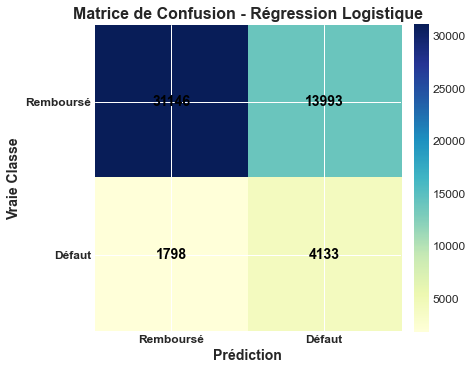

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=[0,1])

# Labels in French for clarity
class_labels = ['Remboursé', 'Défaut']

# Create figure
fig, ax = plt.subplots(figsize=(6,6))

# Plot matrix with colormap
im = ax.imshow(cm, cmap='YlGnBu')  # professional color map

# Annotate the matrix with counts
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=14, fontweight='bold')

# Set ticks and labels
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(class_labels, fontsize=12, fontweight='bold')
ax.set_yticklabels(class_labels, fontsize=12, fontweight='bold')

# Axis labels and title
ax.set_xlabel('Prédiction', fontsize=14, fontweight='bold')
ax.set_ylabel('Vraie Classe', fontsize=14, fontweight='bold')
plt.title("Matrice de Confusion - Régression Logistique", fontsize=16, fontweight='bold')

# Add colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=12)

plt.show()


### Key metrics

- #### Résumé des métriques clés

Le modèle présente une **accuracy globale de 69 %**, avec un **recall élevé pour les prêts à risque** (70 %), ce qui est essentiel pour identifier les défauts potentiels. La précision plus faible (23 %) pour la classe des défauts indique que certains emprunteurs à faible risque sont signalés à tort, mais le compromis est acceptable pour réduire les pertes liées aux prêts non performants.

In [10]:
# 4) Evaluation

print("Logistic Regression with Class")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report (Test Set):\n", classification_report(y_test, y_test_pred, zero_division=0))


Logistic Regression with Class
Accuracy: 0.6907969453691012

Classification Report (Test Set):
               precision    recall  f1-score   support

           0       0.95      0.69      0.80     45139
           1       0.23      0.70      0.34      5931

    accuracy                           0.69     51070
   macro avg       0.59      0.69      0.57     51070
weighted avg       0.86      0.69      0.75     51070



- #### Contexte Business

Ces résultats montrent que le modèle permet de **cibler efficacement les emprunteurs à risque** tout en minimisant les interventions inutiles sur les clients fiables. L’institution peut ainsi prioriser ses efforts de suivi et de prévention du défaut, optimisant à la fois la sécurité du portefeuille de prêts et les ressources opérationnelles.


### ROC curve

- #### Résumé de la courbe ROC

Le modèle atteint un **AUC de 0,76**, indiquant une **capacité correcte à distinguer les emprunteurs à risque des emprunteurs fiables**. Cela montre que le modèle est utile pour guider les décisions de crédit, même si des améliorations sont possibles pour maximiser la discrimination.



AUC Score: 0.76


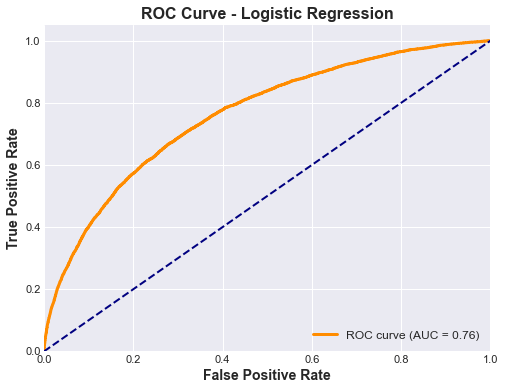

In [11]:

# Predict probabilities for the positive class (Churn=True)
y_proba = logreg.predict_proba(X_test_processed)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Compute AUC
auc_score = roc_auc_score(y_test, y_proba)

# Print AUC score
print(f"AUC Score: {auc_score:.2f}")

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
plt.title('ROC Curve - Logistic Regression', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)

# plt.savefig("Images/logisticroc.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()


- #### Contexte Business

Un AUC de 0,76 signifie que l’institution peut **identifier la majorité des prêts à risque** tout en limitant les faux positifs. Cela permet de **prioriser les actions de prévention du défaut** et de protéger le portefeuille de prêts de manière efficace, tout en utilisant judicieusement les ressources.


### 2. Modèles Optimisés
---

Dans cette section, nous construisons des modèles plus puissants que la baseline pour améliorer la prédiction du **risque de défaut**.  

Ces modèles capturent des **relations complexes et non-linéaires** entre les variables, et sont conçus pour mieux détecter les emprunteurs à risque tout en gérant le **déséquilibre des classes**.  

Nous commencerons par le **Random Forest**, suivi de **XGBoost**, en ajustant les hyperparamètres pour maximiser la performance et fournir des insights exploitables pour les décisions de crédit.


#### a) Random Forest (Modèle Optimisé)
---

Dans cette étape, nous construisons un **modèle Random Forest optimisé** pour prédire le **risque de défaut de remboursement des prêts**.  

Random Forest est un modèle d'ensemble robuste capable de capturer des **relations complexes et non-linéaires** entre les variables.  

Nous suivrons une approche structurée :  

- **Model Building :** Entraînement sur les données prétraitées avec **RandomizedSearchCV** pour trouver les meilleurs hyperparamètres (`n_estimators`, `max_depth`, `min_samples_split`).  
- **Model Evaluation :** Performance mesurée via **accuracy, recall, précision, F1-score, AUC**, matrices de confusion et courbes ROC.  
- **Insights :** Résultats interprétés pour guider la **gestion du risque de crédit** et optimiser les décisions de prêt.


### Model Building

In [12]:
#1️ Définir le modèle de base
# ---------------------------------------
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',   # handle class imbalance
    n_jobs=-1
)
# 2️ Définir la grille d'hyperparamètres
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
# 3️ RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=25,            # reduced for faster run
    cv=3,                 # 3-fold cross-validation
    scoring='roc_auc',    # AUC is more relevant for imbalance
    verbose=2,            # see progress
    random_state=42,
    n_jobs=-1             # use all processors
)


### Model Building

In [13]:
# 5️ Entraîner le modèle optimisé
rf_random.fit(X_train_processed, y_train)

print("✅ Random Forest optimized successfully!")
print("🔧 Best parameters found:")
print(rf_random.best_params_)

# 6️ Predictions
y_train_pred_rf = rf_random.predict(X_train_processed)
y_test_pred_rf = rf_random.predict(X_test_processed)

# Probabilités pour ROC AUC
yy_train_prob_rf = rf_random.predict_proba(X_train_processed)[:, 1]
y_test_prob_rf = rf_random.predict_proba(X_test_processed)[:, 1]

print("✅ Predictions generated for train and test sets.")

Fitting 3 folds for each of 25 candidates, totalling 75 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  5.5min
[Parallel(n_jobs=-1)]: Done  75 out of  75 | elapsed: 16.1min finished


✅ Random Forest optimized successfully!
🔧 Best parameters found:
{'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}
✅ Predictions generated for train and test sets.


### Model Evaluation

### confusion matrix

Le **modèle Random Forest optimisé** démontre une **forte capacité à identifier les emprunteurs fiables** tout en maintenant une bonne détection des profils à risque.  
Comme le montre la matrice de confusion ci-dessous :  

- **TN = 33 792** → une majorité de clients non défaillants correctement identifiés, évitant les refus injustifiés,  
- **TP = 3 709** → un volume appréciable d’emprunteurs à risque correctement détectés,  
- **FN = 2 222** → quelques cas risqués encore manqués, laissant place à une amélioration du rappel,  
- **FP = 11 347** → certains bons clients signalés à tort, un compromis acceptable pour maximiser la prudence du système.  


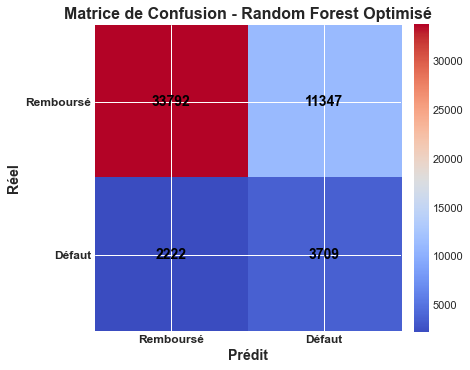

In [14]:
# 1️ Matrice de confusion
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Remboursé", "Défaut"])

fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(cm_rf, cmap='coolwarm')

# Chiffres au centre des cases
for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        ax.text(j, i, cm_rf[i, j], ha='center', va='center', fontsize=14, fontweight='bold', color='black')

ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(["Remboursé", "Défaut"], fontsize=12, fontweight='bold')
ax.set_yticklabels(["Remboursé", "Défaut"], fontsize=12, fontweight='bold')
ax.set_xlabel('Prédit', fontsize=14, fontweight='bold')
ax.set_ylabel('Réel', fontsize=14, fontweight='bold')
plt.title("Matrice de Confusion - Random Forest Optimisé", fontsize=16, fontweight='bold')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()



### 💼 Contexte Business
Ce modèle constitue un **outil stratégique de gestion du risque de crédit**.  
Il permet à l’institution financière de **réduire les pertes liées aux défauts de paiement**, tout en **optimisant la sélection des emprunteurs**.  
Bien que quelques clients à faible risque soient injustement catégorisés comme « risqués », cette approche préventive protège le portefeuille de prêts contre des pertes plus coûteuses à long terme.  

En somme, le modèle Random Forest aide la banque à **trouver un équilibre intelligent entre prudence et opportunité**, favorisant une croissance durable et une meilleure stabilité financière.


### Key metrics

The Random Forest model performs well overall, correctly classifying about **three-quarters of all loans**.  
It captures over **60% of actual defaults**, which is valuable for minimizing **credit risk**, even though some **false positives** persist.  
This trade-off remains acceptable, as detecting **risky borrowers** is more critical than missing them.  
The **F1-score** reflects a good balance between precision and recall, and the **AUC (0.75)** confirms that the model effectively distinguishes between **reliable and risky clients**.

In [15]:
# 2️ Metrics clés
accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
precision_rf = precision_score(y_test, y_test_pred_rf)
recall_rf = recall_score(y_test, y_test_pred_rf)
f1_rf = f1_score(y_test, y_test_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_test_prob_rf)

print(f"Accuracy : {accuracy_rf:.3f}")
print(f"Precision : {precision_rf:.3f}")
print(f"Recall : {recall_rf:.3f}")
print(f"F1-score : {f1_rf:.3f}")
print(f"ROC AUC : {roc_auc_rf:.3f}\n")

print("Classification Report :\n")
print(classification_report(y_test, y_test_pred_rf, target_names=["Remboursé", "Défaut"]))



Accuracy : 0.734
Precision : 0.246
Recall : 0.625
F1-score : 0.353
ROC AUC : 0.753

Classification Report :

              precision    recall  f1-score   support

   Remboursé       0.94      0.75      0.83     45139
      Défaut       0.25      0.63      0.35      5931

    accuracy                           0.73     51070
   macro avg       0.59      0.69      0.59     51070
weighted avg       0.86      0.73      0.78     51070




### 💼 Contexte Business
Pour l’institution financière, ce modèle constitue une **avancée stratégique** :  
il améliore la **prévention du risque de défaut**, permettant aux analystes de **cibler plus efficacement les clients à risque** tout en **minimisant les pertes potentielles**.  
Bien que le modèle reste perfectible en précision, il fournit déjà une **base fiable pour la prise de décision** et la mise en place de politiques de crédit plus sécurisées et rentables.

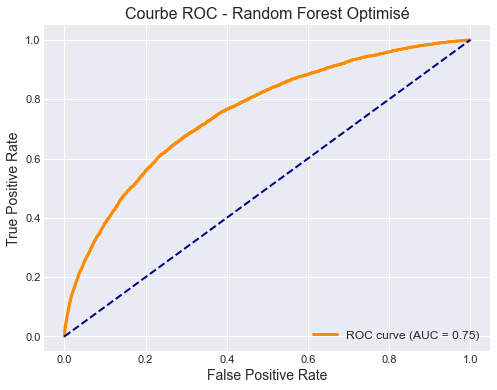

In [16]:
# 3️ Courbe ROC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_test_prob_rf)
plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc_rf:.2f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Courbe ROC - Random Forest Optimisé', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.show()

In [22]:
#  Cell A — XGBoost optimisé : entraînement + prédictions
# 0) Calculer scale_pos_weight pour compenser le déséquilibre (pos = défaut)
# ------------------------------
# ratio = (nombre de négatifs) / (nombre de positifs)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"🔢 scale_pos_weight = {scale_pos_weight:.2f} (neg={neg}, pos={pos})")

# ------------------------------
# 1) Définir le classifieur XGBoost de base
# ------------------------------
xgb_base = XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',   # métrique interne (nous utiliserons AUC pour la recherche)
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    scale_pos_weight=scale_pos_weight  # pondération pour la classe minoritaire
)

# ------------------------------
# 2) Grille d'hyperparamètres (raisonnable pour vitesse/qualité)
# ------------------------------
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5]
}

# ------------------------------
# 3) RandomizedSearchCV (rapide et efficace)
# ------------------------------
xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=25,               # nombre d'essais aléatoires (ajuster si besoin)
    scoring='roc_auc',       # optimiser AUC (utile pour déséquilibre)
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)



🔢 scale_pos_weight = 7.61 (neg=180555, pos=23722)


## Model Building

In [ ]:
# ------------------------------
# 4) Lancer la recherche d'hyperparamètres sur les données prétraitées
# ------------------------------
xgb_search.fit(X_train_processed, y_train)
print("✅ XGBoost optimisé entraîné avec succès.")
print("🔧 Meilleurs hyperparamètres :")
print(xgb_search.best_params_)

# ------------------------------
# 5) Entraîner le modèle final (retrain) si tu veux sur l'ensemble train complet
#    - ici xgb_search.best_estimator_ est déjà entraîné sur les folds, mais on peut
#      réentraîner sur tout l'ensemble d'entraînement si souhaité :
# ------------------------------
best_xgb = xgb_search.best_estimator_

# ------------------------------
# 6) Prédictions et probabilités pour l'évaluation
# ------------------------------
y_train_pred_xgb = best_xgb.predict(X_train_processed)
y_test_pred_xgb  = best_xgb.predict(X_test_processed)

y_train_proba_xgb = best_xgb.predict_proba(X_train_processed)[:, 1]
y_test_proba_xgb  = best_xgb.predict_proba(X_test_processed)[:, 1]

print("✅ Prédictions (train & test) et probabilités générées.")


Fitting 3 folds for each of 25 candidates, totalling 75 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  4.3min


## Evaluation

### confusion Matrix

In [ ]:
# ==============================
# — Évaluation du modèle XGBoost optimisé

# ------------------------------
# 1) Matrice de confusion (jolie visualisation)
# ------------------------------
cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["Remboursé", "Défaut"])

fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(cm_xgb, cmap='coolwarm', interpolation='nearest')

# Afficher les nombres en grand et en gras
for i in range(cm_xgb.shape[0]):
    for j in range(cm_xgb.shape[1]):
        ax.text(j, i, cm_xgb[i, j], ha='center', va='center',
                fontsize=14, fontweight='bold', color='black')

ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(["Remboursé", "Défaut"], fontsize=12, fontweight='bold')
ax.set_yticklabels(["Remboursé", "Défaut"], fontsize=12, fontweight='bold')
ax.set_xlabel('Prédit', fontsize=13, fontweight='bold')
ax.set_ylabel('Réel', fontsize=13, fontweight='bold')
plt.title("Matrice de Confusion - XGBoost Optimisé", fontsize=15, fontweight='bold')

# Barre de couleurs (optionnelle)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
# plt.savefig("Images/cm_xgboost_optimise.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()



### Key metrics

In [ ]:
# 2) Metrics clés
accuracy_xgb = accuracy_score(y_test, y_test_pred_xgb)
precision_xgb = precision_score(y_test, y_test_pred_xgb)
recall_xgb = recall_score(y_test, y_test_pred_xgb)
f1_xgb = f1_score(y_test, y_test_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_test_proba_xgb)

print("✅ Metrics (Test set) :")
print(f"Accuracy : {accuracy_xgb:.3f}")
print(f"Precision : {precision_xgb:.3f}")
print(f"Recall : {recall_xgb:.3f}")
print(f"F1-score : {f1_xgb:.3f}")
print(f"ROC AUC : {roc_auc_xgb:.3f}\n")

print("Classification Report :\n")
print(classification_report(y_test, y_test_pred_xgb, target_names=["Remboursé", "Défaut"]))

In [ ]:
# 3) Courbe ROC
# ------------------------------
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_proba_xgb)
plt.figure(figsize=(8,6))
plt.plot(fpr_xgb, tpr_xgb, lw=3, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})', color='darkgreen')
plt.plot([0,1], [0,1], linestyle='--', color='navy', lw=2)
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('Courbe ROC - XGBoost Optimisé', fontsize=15)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
# plt.savefig("Images/roc_xgboost_optimise.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
